# Hyperspectral Target Detection — Demo

This notebook walks through the full pipeline for a single dataset (**Salinas-A**), end to end:

1. Load the hyperspectral image and ground truth
2. Reduce spectral dimensionality (PCA by default; t-SNE / UMAP also available)
3. Extract spatial–spectral patches
4. Train the lightweight hybrid 3D–2D CNN
5. Evaluate and visualize results (ROC curve, confusion matrix, predicted target map)
6. *(Optional)* Compare all three dimensionality reduction methods side by side

This notebook imports directly from `utils.py`, so it stays in sync with the actual pipeline rather than duplicating logic. It expects the dataset files to be present locally under `../HSI_Datasets/` (see the main [README](./README.md) for dataset sourcing/citation); the raw data itself is not included in this repository.

For the full method description, see the accompanying paper: *"Dimensionality Reduction based Convolutional Network for Hyperspectral Target Detection"* (Ghorbanmeyabadi, Imani, and Ghassemian).

In [1]:
from utils import *
import matplotlib.pyplot as plt
%matplotlib inline

c:\Users\r3z8\Documents\vscode\HyperSpectralTargetDetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

We reuse `config.yaml` as the base configuration, then override `dataset` and `reduction_method` explicitly here for clarity in the demo.

In [2]:
config = load_config("config.yaml")
np.random.seed(config["seed_value"])
tf.random.set_seed(config["seed_value"])
config

{'dataset': 'SAA',
 'target_class_num': 12,
 'reduction_method': 'pca',
 'num_components': 3,
 'window_size': 5,
 'test_ratio': 0.1,
 'seed_value': 7,
 'batch_size': 32,
 'epochs': 10,
 'learning_rate': 0.01,
 'patience': 3,
 'data_path': '../HSI_Datasets/'}

## 2. Load data and preprocess

This performs dimensionality reduction (PCA here), spatial patch extraction, and a stratified train/test split. The class-balance check will raise an error if `target_class_num` doesn't match any pixels for the chosen dataset, worth watching for if you change the dataset above.

In [3]:
data, labels = HSIDataLoader.load_dataset(config["dataset"], config["data_path"])

X_train, X_test, y_train, y_test, data_patched, reduction_time = HSIDataLoader.preprocess_data(
    data, labels, config["target_class_num"], config["num_components"],
    config["window_size"], config["test_ratio"], config["seed_value"],
    config["reduction_method"],
)

X_train = X_train.reshape(-1, config["window_size"], config["window_size"], config["num_components"], 1)
X_test = X_test.reshape(-1, config["window_size"], config["window_size"], config["num_components"], 1)

print(f"Train patches: {X_train.shape[0]}, Test patches: {X_test.shape[0]}")

Class balance for target_class_num=12: 1525 target pixels, 5613 background pixels
[PCA] dimensionality reduction took 0.40s
Train patches: 6424, Test patches: 714


## 3. Train the hybrid 3D–2D CNN

Uses the same `build_model()` / `train_model()` as `run.py`, with early stopping on validation loss.

In [4]:
model, history, training_time = train_model(
    config, X_train, y_train, X_test, y_test, config["reduction_method"]
)

print(f"Reduction time: {reduction_time:.2f}s  |  Training time: {training_time:.2f}s  "
      f"|  Total: {reduction_time + training_time:.2f}s")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 5, 3, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 3, 3, 3, 2)     │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 3, 6)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 1, 1, 4)        │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,545 (134.94 KB)

 Trainable params: 34,545 (134.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9434 - loss: 0.1457 - val_accuracy: 0.9743 - val_loss: 0.0824
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9720 - loss: 0.0886 - val_accuracy: 0.9852 - val_loss: 0.0496
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9821 - loss: 0.0564 - val_accuracy: 0.9899 - val_loss: 0.0355
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9835 - loss: 0.0512 - val_accuracy: 0.9922 - val_loss: 0.0327
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9866 - loss: 0.0449 - val_accuracy: 0.9829 - val_loss: 0.0466
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9860 - loss: 0.0443 - val_accuracy: 0.9922 - val_loss: 0.0286
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9850 - loss: 0.0481 - val_accuracy: 0.9899 - val_loss: 0.0335
Epoch 8/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9860 - loss: 0.0413 - val_acc

## 4. Evaluate and visualize

Rather than saving plots to disk (as `run.py` does for batch runs), we display them inline here for a quick, readable demo.

In [5]:
y_pred = model.predict(X_test)

precision = precision_score(y_test, np.round(y_pred))
recall = recall_score(y_test, np.round(y_pred))
f1 = f1_score(y_test, np.round(y_pred))
auc = roc_auc_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Precision: 0.9934
Recall:    0.9804
F1 Score:  0.9868
AUC:       0.9999


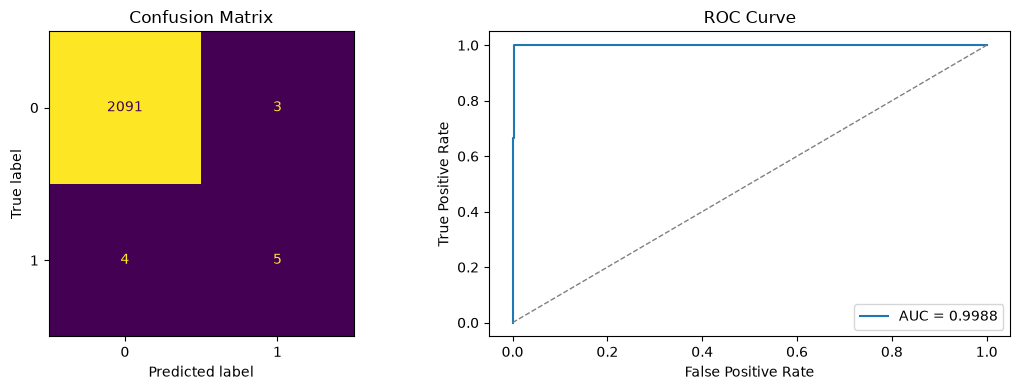

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix
cm = confusion_matrix(y_test, np.round(y_pred))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


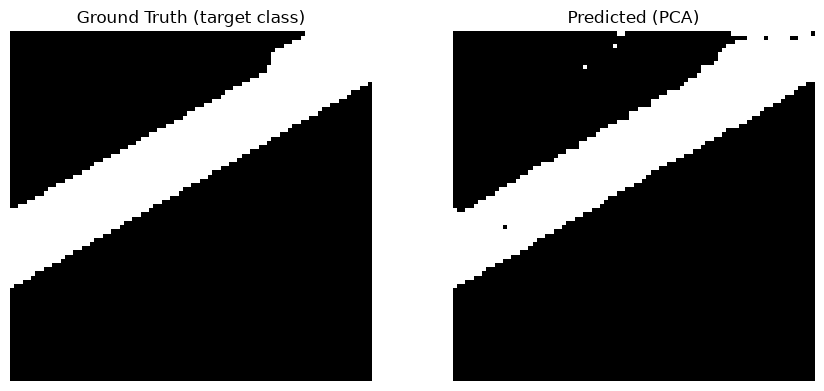

In [6]:
# Predicted target map vs. ground truth, full scene
patched_reshaped = data_patched.reshape(
    data_patched.shape[0], config["window_size"], config["window_size"], config["num_components"], 1
)
y_pred_full = model.predict(patched_reshaped)
result_2d = np.round(y_pred_full).reshape(labels.shape[0], labels.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(labels == config["target_class_num"], cmap="gray")
axes[0].set_title("Ground Truth (target class)")
axes[0].axis("off")

axes[1].imshow(result_2d, cmap="gray")
axes[1].set_title(f"Predicted ({config['reduction_method'].upper()})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Training curves

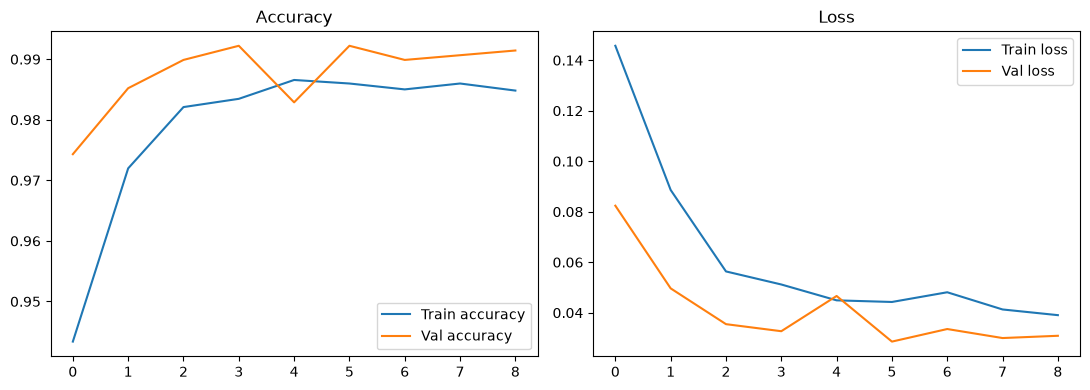

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history.history[metric], label=f"Train {metric}")
    ax.plot(history.history[f"val_{metric}"], label=f"Val {metric}")
    ax.set_title(metric.capitalize())
    ax.legend()
plt.tight_layout()
plt.show()

## 6. *(Optional)* Compare PCA vs. t-SNE vs. UMAP

Reruns the full pipeline for each reduction method on the same dataset and target class, so results are directly comparable. This can take a while for t-SNE/UMAP on larger images — it's fine on Salinas-A but consider skipping this cell for larger datasets like Indian Pines.

This mirrors the comparison reported in the paper (Table II / Figure 6), but for a single dataset rather than the full four-dataset sweep.

In [8]:
results = {}

for method in ["pca", "tsne", "umap"]:
    print(f"\n=== {method.upper()} ===")
    Xtr, Xte, ytr, yte, patched, red_time = HSIDataLoader.preprocess_data(
        data, labels, config["target_class_num"], config["num_components"],
        config["window_size"], config["test_ratio"], config["seed_value"], method,
    )
    Xtr = Xtr.reshape(-1, config["window_size"], config["window_size"], config["num_components"], 1)
    Xte = Xte.reshape(-1, config["window_size"], config["window_size"], config["num_components"], 1)

    m, h, train_time = train_model(config, Xtr, ytr, Xte, yte, method)
    yp = m.predict(Xte)

    results[method] = {
        "AUC": roc_auc_score(yte, yp),
        "Precision": precision_score(yte, np.round(yp)),
        "Recall": recall_score(yte, np.round(yp)),
        "F1": f1_score(yte, np.round(yp)),
        "Reduction Time (s)": red_time,
        "Training Time (s)": train_time,
    }

pd.DataFrame(results).T


=== PCA ===
Class balance for target_class_num=12: 1525 target pixels, 5613 background pixels


[PCA] dimensionality reduction took 0.87s


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5, 5, 3, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 3, 3, 3, 2)     │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 3, 3, 6)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1, 1, 4)        │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,545 (134.94 KB)

...

 Total params: 34,545 (134.94 KB)

 Trainable params: 34,545 (134.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9128 - loss: 0.2171 - val_accuracy: 0.9595 - val_loss: 0.1308
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9702 - loss: 0.0935 - val_accuracy: 0.9868 - val_loss: 0.0353
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9798 - loss: 0.0729 - val_accuracy: 0.9883 - val_loss: 0.0338
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9778 - loss: 0.0623 - val_accuracy: 0.9790 - val_loss: 0.0373
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9809 - loss: 0.0643 - val_accuracy: 0.9837 - val_loss: 0.0503
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9786 - loss: 0.0791 - val_accuracy: 0.9868 - val_loss: 0.0310
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9838 - loss: 0.0539 - val_accuracy: 0.9829 - val_loss: 0.0302
Epoch 8/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9731 - loss: 0.0787 - val_acc

,AUC,Precision,Recall,F1,Reduction Time (s),Training Time (s)
pca,0.999359,0.986667,0.967320,0.976898,0.873996,19.068098
tsne,0.996365,0.932099,0.986928,0.958730,273.705605,20.065057
umap,0.993068,0.892857,0.980392,0.934579,118.226263,34.663108


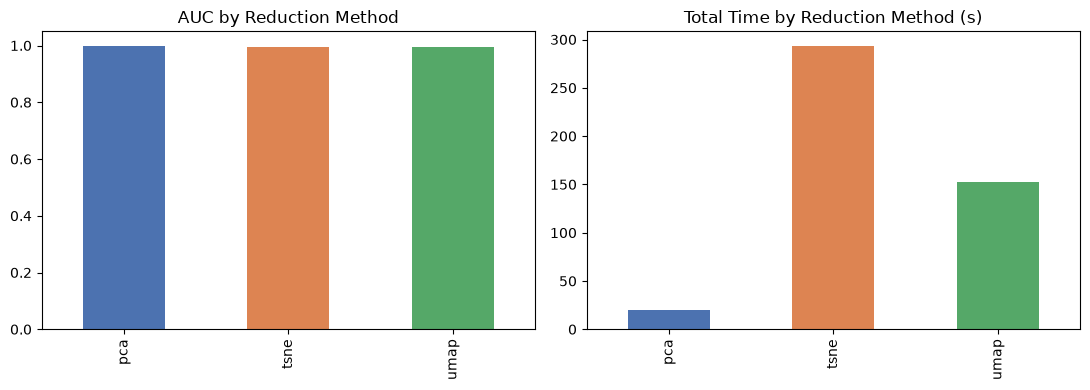

In [9]:
results_df = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
results_df["AUC"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("AUC by Reduction Method")
axes[0].set_ylim(0, 1.05)

(results_df["Reduction Time (s)"] + results_df["Training Time (s)"]).plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"]
)
axes[1].set_title("Total Time by Reduction Method (s)")

plt.tight_layout()
plt.show()